# Модуль 25. Как устроена область

Ноутбук к [модулю 25](https://drobyshevdev.github.io/lemma/modules/25-how-the-field-is-organised/).

Почему лидерборд — плохой источник истины. Три механизма, которые это ломают:

1. **Утечка бенчмарка.** Сообщество подаёт сотни методов на один публичный тест — балл лидера ползёт вверх, а на свежем тесте стоит на месте.
2. **Гонка за SOTA.** «Лучший на публичном тесте» систематически хуже на свежем — регрессия к среднему.
3. **Насыщение.** Когда все у потолка, порядок мест определяется шумом, а не качеством.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(25)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; GOOD = "#4a9d7f"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

Q0 = 80.0     # средний истинный уровень методов
SD_Q = 1.0    # реальный разброс качества между методами (небольшой)
SD_T = 2.0    # шум конечного тестового набора (публичного и свежего)

## 1. Утечка бенчмарка

Каждый метод имеет истинное качество `q`. Публичный тест меряет его с шумом (конечная выборка): `публичный = q + шум`. Свежий тест — с независимым шумом: `свежий = q + другой шум`. Лидер выбирается по **публичному** баллу. Посмотрим, что происходит с ростом числа поданных методов `M`.

In [2]:
def leader_scores(M, trials=4000):
    pub_lead = np.empty(trials); fresh_of_lead = np.empty(trials)
    for t in range(trials):
        q = rng.normal(Q0, SD_Q, M)
        public = q + rng.normal(0, SD_T, M)
        fresh  = q + rng.normal(0, SD_T, M)
        i = np.argmax(public)              # лидера выбрали по публичному тесту
        pub_lead[t] = public[i]
        fresh_of_lead[t] = fresh[i]        # его же результат на свежих данных
    return pub_lead.mean(), fresh_of_lead.mean()

Ms = np.array([2, 5, 10, 25, 50, 100, 200, 400])
pub = np.array([leader_scores(M)[0] for M in Ms])
fresh = np.array([leader_scores(M)[1] for M in Ms])

for M, p, f in zip(Ms, pub, fresh):
    print("M=%3d  публичный балл лидера %.2f   на свежем тесте %.2f   разрыв %+.2f" % (M, p, f, p - f))

M=  2  публичный балл лидера 81.27   на свежем тесте 80.26   разрыв +1.02
M=  5  публичный балл лидера 82.59   на свежем тесте 80.56   разрыв +2.04
M= 10  публичный балл лидера 83.42   на свежем тесте 80.70   разрыв +2.71
M= 25  публичный балл лидера 84.38   на свежем тесте 80.88   разрыв +3.50
M= 50  публичный балл лидера 85.05   на свежем тесте 80.98   разрыв +4.06
M=100  публичный балл лидера 85.59   на свежем тесте 81.09   разрыв +4.50
M=200  публичный балл лидера 86.15   на свежем тесте 81.22   разрыв +4.92
M=400  публичный балл лидера 86.64   на свежем тесте 81.30   разрыв +5.34


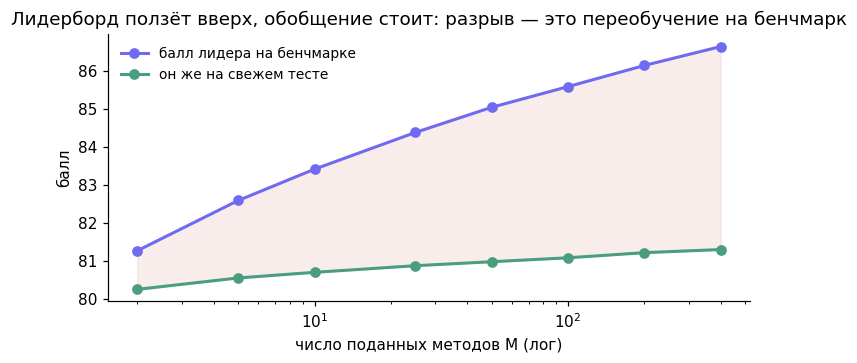

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(Ms, pub, "o-", color=ACCENT, lw=2, label="балл лидера на бенчмарке")
ax.plot(Ms, fresh, "o-", color=GOOD, lw=2, label="он же на свежем тесте")
ax.fill_between(Ms, fresh, pub, color=BAD, alpha=0.12)
ax.set_xscale("log")
ax.set_xlabel("число поданных методов M (лог)"); ax.set_ylabel("балл")
ax.set_title("Лидерборд ползёт вверх, обобщение стоит: разрыв — это переобучение на бенчмарк")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Истинного прогресса нет — пул методов один и тот же по качеству. Но чем больше методов подано на публичный тест, тем выше балл лидера: из множества шумных попыток верх занимает самая удачная. На свежем тесте эта удача не повторяется, и результат стоит около истинного уровня. Красная область между кривыми — переобучение на бенчмарк: рост, которого нет в обобщении.

## 2. Гонка за SOTA — регрессия к среднему

Возьмём один срез: `M` методов, посмотрим публичный и свежий балл каждого. Лидер по публичному тесту — и где он на свежем.

In [4]:
M = 120
q = rng.normal(Q0, SD_Q, M)
public = q + rng.normal(0, SD_T, M)
fresh  = q + rng.normal(0, SD_T, M)
i_pub = int(np.argmax(public))     # лидер публичного теста
i_fresh = int(np.argmax(fresh))    # настоящий лидер на свежих данных

# как часто публичный №1 действительно №1 на свежем тесте
def top1_match(trials=5000):
    hit = 0
    for _ in range(trials):
        qq = rng.normal(Q0, SD_Q, M)
        pp = qq + rng.normal(0, SD_T, M); ff = qq + rng.normal(0, SD_T, M)
        hit += np.argmax(pp) == np.argmax(ff)
    return hit / trials

print("Публичный №1: балл %.2f, на свежем тесте %.2f (ранг %d из %d)" % (
    public[i_pub], fresh[i_pub], (fresh > fresh[i_pub]).sum() + 1, M))
print("Свежий №1:    публичный балл %.2f, свежий %.2f" % (public[i_fresh], fresh[i_fresh]))
print("Публичный №1 оказывается №1 на свежем тесте лишь в %.0f%% случаев" % (100 * top1_match()))

Публичный №1: балл 84.65, на свежем тесте 80.39 (ранг 61 из 120)
Свежий №1:    публичный балл 84.39, свежий 84.83
Публичный №1 оказывается №1 на свежем тесте лишь в 3% случаев


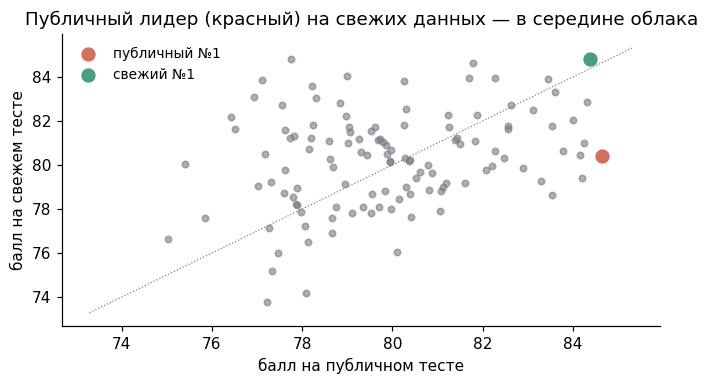

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.scatter(public, fresh, s=18, color=GREY, alpha=0.6)
ax.scatter([public[i_pub]], [fresh[i_pub]], s=70, color=BAD, zorder=5, label="публичный №1")
ax.scatter([public[i_fresh]], [fresh[i_fresh]], s=70, color=GOOD, zorder=5, label="свежий №1")
lim = [min(public.min(), fresh.min()) - 0.5, max(public.max(), fresh.max()) + 0.5]
ax.plot(lim, lim, color=GREY, ls=":", lw=0.8)
ax.set_xlabel("балл на публичном тесте"); ax.set_ylabel("балл на свежем тесте")
ax.set_title("Публичный лидер (красный) на свежих данных — в середине облака")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Публичный лидер сидит справа (высокий публичный балл), но по вертикали — в середине облака: на свежем тесте он обычный. Настоящий лидер свежих данных (зелёный) на публичном тесте ничем не выделялся. Совпадают эти двое редко — «первое место» на бенчмарке слабо предсказывает первое место в реальности.

## 3. Насыщение

Когда все методы у потолка, реальные различия между ними (`SD_Q`) становятся меньше шума теста (`SD_T`). Порядок мест начинает определять шум. Посмотрим, как совпадение публичного и свежего лидера падает с сокращением реального разброса.

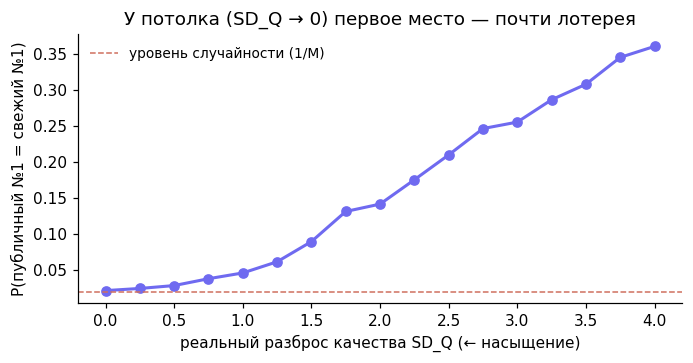

SD_Q=4.0: совпадение 36% | SD_Q=0.5: 3% | случайность 2%


In [6]:
def top1_match_for(sd_q, M=50, trials=4000):
    hit = 0
    for _ in range(trials):
        qq = rng.normal(Q0, sd_q, M)
        pp = qq + rng.normal(0, SD_T, M); ff = qq + rng.normal(0, SD_T, M)
        hit += np.argmax(pp) == np.argmax(ff)
    return hit / trials

sds = np.linspace(0.0, 4.0, 17)
match = np.array([top1_match_for(sd) for sd in sds])
chance = 1.0 / 50

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(sds, match, "o-", color=ACCENT, lw=2)
ax.axhline(chance, color=BAD, ls="--", lw=1, label="уровень случайности (1/M)")
ax.set_xlabel("реальный разброс качества SD_Q (← насыщение)"); ax.set_ylabel("P(публичный №1 = свежий №1)")
ax.set_title("У потолка (SD_Q → 0) первое место — почти лотерея")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("SD_Q=4.0: совпадение %.0f%% | SD_Q=0.5: %.0f%% | случайность %.0f%%" % (
    100 * match[-1], 100 * top1_match_for(0.5), 100 * chance))

Когда методы реально различаются (`SD_Q` большой), публичный лидер обычно и есть лучший. По мере насыщения — когда все подтягиваются к потолку и реальные различия тают — совпадение падает к уровню случайного тыка. На насыщенном бенчмарке +0.1% наверху не значит ничего: это шум теста, а не превосходство метода.

## Что дальше

- Постройте «честный» лидерборд с доверительными интервалами и посчитайте, сколько верхних мест статистически неразличимы.
- Сравните ранжирование по среднему и по худшему срезу — найдите лидера по среднему, проваленного на срезе (это регресс из [модуля 23](https://drobyshevdev.github.io/lemma/modules/23-evaluating-agents/)).
- В [модуле 26](https://drobyshevdev.github.io/lemma/programme/) — единственная настоящая проверка: воспроизвести результат самому, а не верить месту в рейтинге.